# Phase 3: Kalman Filter Smoothing

In Phase 2 the decoder made **one guess per trial**. A real brain-controlled arm doesn't wait for trials. It needs a **continuous stream** of guesses, say ten per second, and each one is noisy. If the arm obeyed every raw guess, it would twitch left and right constantly.

![Kalman smoothing concept](../images/kalman_smoothing_concept.png)

The fix is the same idea as in the orbital project: don't trust any single noisy measurement, blend it with what you already believe.

**The model.** Let $x_t$ be the person's true intent at time $t$, a number from $-1$ (left) to $+1$ (right). We assume intent mostly stays put but can drift or switch:

$$x_t = x_{t-1} + w_t, \quad w_t \sim \mathcal{N}(0, Q) \qquad \text{(process model)}$$

The decoder's output $z_t$ is a noisy view of it:

$$z_t = x_t + v_t, \quad v_t \sim \mathcal{N}(0, R) \qquad \text{(measurement model)}$$

**The filter** repeats two steps for every new reading:

| Step | Equations | Meaning |
|---|---|---|
| Predict | $\hat{x}^- = \hat{x}, \quad P^- = P + Q$ | "Intent is probably what it was." Uncertainty grows a little. |
| Update | $K = \dfrac{P^-}{P^- + R}, \quad \hat{x} = \hat{x}^- + K\,(z - \hat{x}^-), \quad P = (1-K)\,P^-$ | Move the estimate toward the new reading, by the Kalman gain $K$. |

![One Kalman step](../images/kalman_step.png)

**What $Q$ and $R$ do:** large $R$ (noisy decoder) gives a small gain $K$, so the filter trusts its past and the output is smoother. Large $Q$ (intent changes fast) gives a large gain, so the filter reacts faster but is jumpier. Smoothness and reaction speed are a trade-off, and we'll measure it.

**Differences from the orbital filter.** There the process model was real physics (gravity), with Jacobians recomputed at every step. Here the process model is the simplest possible one, "intent stays put", and everything is one-dimensional. The predict/update structure is the same.

**Plan for this notebook:**

1. Load a subject's trials and cut each into overlapping short windows
2. Classify every window to get a stream of out-of-sample guesses over time
3. Chain the trials into one continuous "session"
4. Apply the Kalman filter and measure what it fixes
5. Sweep $Q$ to see the smoothness vs. speed trade-off

In [11]:
import numpy as np                                   # arrays and math
import matplotlib.pyplot as plt                      # plotting
import mne                                           # EEG loading and processing
from mne.datasets import eegbci                      # PhysioNet dataset loader
from mne.io import concatenate_raws, read_raw_edf    # reading and combining recordings
from mne.decoding import CSP                         # Common Spatial Patterns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold

np.random.seed(42)
mne.set_log_level("WARNING")
print(f"MNE version: {mne.__version__}")

MNE version: 1.13.2


In [12]:
def load_subject(subject, tmin=0.5, tmax=4.0):
    """Load, filter and epoch one subject's left/right imagery trials."""
    paths = eegbci.load_data(subject, [4, 8, 12])
    raw = concatenate_raws([read_raw_edf(p, preload=True) for p in paths])
    eegbci.standardize(raw)
    raw.filter(l_freq=8.0, h_freq=30.0, verbose=False)
    events, _ = mne.events_from_annotations(raw, event_id={"T1": 2, "T2": 3}, verbose=False)
    ep = mne.Epochs(raw, events, event_id={"left": 2, "right": 3}, tmin=-1.0, tmax=4.0,
                    baseline=None, picks="eeg", preload=True, verbose=False)
    ep.crop(tmin=tmin, tmax=tmax)
    return ep.get_data(), ep.events[:, 2], ep.info["sfreq"]

subject = 7
X, y, sfreq = load_subject(subject)

print(f"Subject {subject}: X shape = {X.shape}")
print(f"Sampling rate: {sfreq:.0f} Hz")
print(f"Left trials: {np.sum(y == 2)}   Right trials: {np.sum(y == 3)}")

Subject 7: X shape = (45, 64, 561)
Sampling rate: 160 Hz
Left trials: 23   Right trials: 22


## Step 1: Turn Each Trial into a Stream of Guesses

A real-time system can't wait for a whole trial to finish. Instead it looks at the **most recent 1.5 seconds** of EEG, makes a guess, then slides forward by 0.1 s and guesses again, ten times per second.

- **Window length:** 1.5 s (240 samples). Long enough for a stable power estimate, short enough to react.
- **Step:** 0.1 s (16 samples), so consecutive windows overlap heavily.
- **Causal:** each guess uses only the past. We time-stamp it at the window's *end*, as a live system would.
- Each trial gives 21 windows, so the 45 trials give 945 guesses in total.
![Sliding window](../images/sliding_window.png)

**No cheating:** neighbouring windows from the same trial look almost identical. If some landed in the training set and others in the test set, the model would just recognize the trial. So we split by **trial**: all 21 windows of a trial are either all training or all test. Each guess you'll see was made by a model that never saw that trial. As in Phase 2, CSP is fit inside each training fold.

The output of the decoder is $z_t = P(\text{right})$ for each window, a number between 0 (confident left) and 1 (confident right). This is the noisy stream the Kalman filter will smooth.



In [13]:
# Cut every trial into overlapping 1.5 s windows, stepping 0.1 s
win_len = int(1.5 * sfreq)    # 240 samples
step = int(0.1 * sfreq)       # 16 samples
starts = list(range(0, X.shape[2] - win_len + 1, step))
win_end_times = 0.5 + (np.array(starts) + win_len) / sfreq   # seconds after the cue (window end)

Xw = np.stack([X[:, :, s:s + win_len] for s in starts], axis=1)   # (trials, windows, channels, samples)
n_trials, n_win = Xw.shape[:2]
print(f"Windows per trial: {n_win}   Window shape: {Xw.shape[2:]}")

clf = Pipeline([
    ("csp", CSP(n_components=4, reg=None, log=True)),
    ("lda", LinearDiscriminantAnalysis()),
])

# Out-of-sample P(right) for every window. Split by TRIAL so no trial is in both train and test.
p_right = np.zeros((n_trials, n_win))
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for train_idx, test_idx in skf.split(X, y):
    X_train = Xw[train_idx].reshape(-1, *Xw.shape[2:])
    y_train = np.repeat(y[train_idx], n_win)
    clf.fit(X_train, y_train)

    X_test = Xw[test_idx].reshape(-1, *Xw.shape[2:])
    p_right[test_idx] = clf.predict_proba(X_test)[:, 1].reshape(len(test_idx), n_win)   # class 3 = right

is_right = (y == 3)
window_acc = np.mean((p_right > 0.5) == is_right[:, None])
print(f"Window-level accuracy (raw decoder): {window_acc:.3f}")
print(f"Total guesses: {p_right.size}")

Windows per trial: 21   Window shape: (64, 240)
Window-level accuracy (raw decoder): 0.957
Total guesses: 945


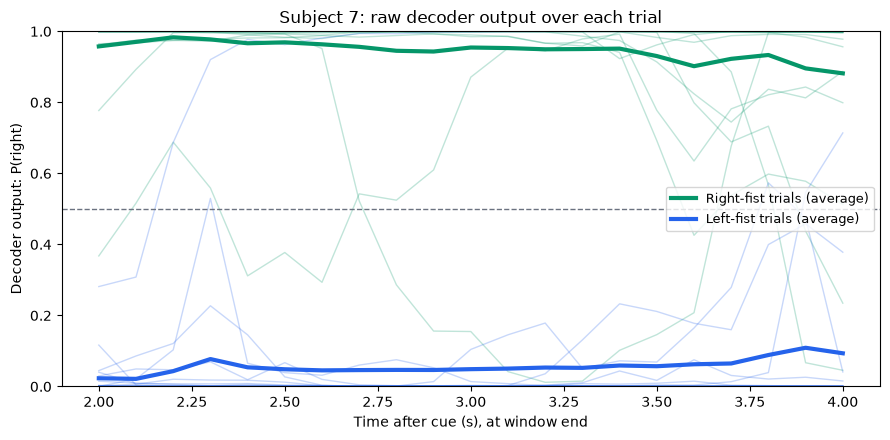

In [14]:
fig, ax = plt.subplots(figsize=(9, 4.5))

for i in range(n_trials):
    ax.plot(win_end_times, p_right[i], color="#059669" if is_right[i] else "#2563eb", alpha=0.25, linewidth=1)

ax.plot(win_end_times, p_right[is_right].mean(axis=0), color="#059669", linewidth=3, label="Right-fist trials (average)")
ax.plot(win_end_times, p_right[~is_right].mean(axis=0), color="#2563eb", linewidth=3, label="Left-fist trials (average)")
ax.axhline(0.5, color="#6b7280", linestyle="--", linewidth=1)

ax.set_xlabel("Time after cue (s), at window end")
ax.set_ylabel("Decoder output: P(right)")
ax.set_ylim(0, 1)
ax.set_title(f"Subject {subject}: raw decoder output over each trial")
ax.legend(loc="center right", fontsize=9)
plt.tight_layout()
plt.show()

## Step 2: Chain the Trials into a Continuous Session

To mimic real use, we line up all 45 trials end to end, 21 guesses each, into one stream of 945 guesses (one every 0.1 s). The person's true intent switches between left and right at trial boundaries, so the filter has to cope with **abrupt switches**, not just steady states.

We rescale each guess to $z_t = 2P(\text{right}) - 1$, which runs from $-1$ (sure left) to $+1$ (sure right). The decision is the sign: $z_t > 0$ means "right".

**How we'll judge a signal** (raw or smoothed), using three numbers:

| Metric | Meaning | Better is |
|---|---|---|
| Accuracy | Fraction of time steps where the sign matches the true intent | higher |
| Flips | Times the sign changes *within* a trial, when the true intent didn't change | lower |
| Lag | At a left↔right switch, seconds until the sign is correct | lower |

![Four metrics](../images/metrics_explained.png)
A raw stream has no lag but may flip a lot. A heavily smoothed stream has few flips but reacts slowly. The goal is a good middle.

In [19]:
# One continuous stream: trials in recording order, 21 guesses each
z_stream = (2 * p_right - 1).reshape(-1)                       # decoder reading in [-1, +1]
truth_stream = np.repeat(np.where(is_right, 1, -1), n_win)     # true intent: -1 left, +1 right
dt = 0.1
t_stream = np.arange(len(z_stream)) * dt

def evaluate(est):
    """Accuracy, regressions, jitter and lag for a stream of estimates."""
    E = est.reshape(n_trials, n_win)
    correct = (E > 0) == is_right[:, None]
    acc = float(correct.mean())
    # regression: within a trial, the estimate goes from correct to wrong
    regressions = int(np.sum(correct[:, :-1] & ~correct[:, 1:]))
    # jitter: average step-to-step change, measured only in trials with NO switch at the start,
    # so legitimate left<->right transitions are not counted as noise
    steady = np.array([k > 0 and is_right[k] == is_right[k - 1] for k in range(n_trials)])
    jitter = float(np.mean(np.abs(np.diff(E[steady], axis=1))))
    # lag: seconds after a left<->right switch until the sign is correct
    lags = []
    for k in range(1, n_trials):
        if is_right[k] != is_right[k - 1]:
            c = correct[k]
            lags.append((np.argmax(c) if c.any() else n_win) * dt)
    return acc, regressions, jitter, float(np.mean(lags))

acc, reg, jit, lag = evaluate(z_stream)
print(f"RAW decoder:  accuracy = {acc:.3f}   regressions = {reg}   jitter = {jit:.3f}   lag = {lag:.2f} s")

RAW decoder:  accuracy = 0.957   regressions = 9   jitter = 0.036   lag = 0.00 s


## Step 3: The Kalman Filter

We now implement the filter from the intro: one number $\hat{x}$ (the estimated intent) and its uncertainty $P$.

**Choosing $R$ (measurement noise):** this is how far the decoder's readings typically stray from the true intent. We estimate it empirically as the variance of $z_t - x_t$ over the session, the same approach we used for the orbital filter. (It uses the true labels, but only to calibrate the noise level.)

**Choosing $Q$ (process noise):** how fast intent is allowed to change. We start with $Q = 0.05$ and sweep it in the next step.

R (measurement noise) = 0.153   Q (process noise) = 0.05
Steady-state Kalman gain ≈ 0.431
RAW decoder  : accuracy = 0.957   regressions = 9   jitter = 0.036   lag = 0.00 s
KALMAN filter: accuracy = 0.934   regressions = 5   jitter = 0.024   lag = 0.08 s


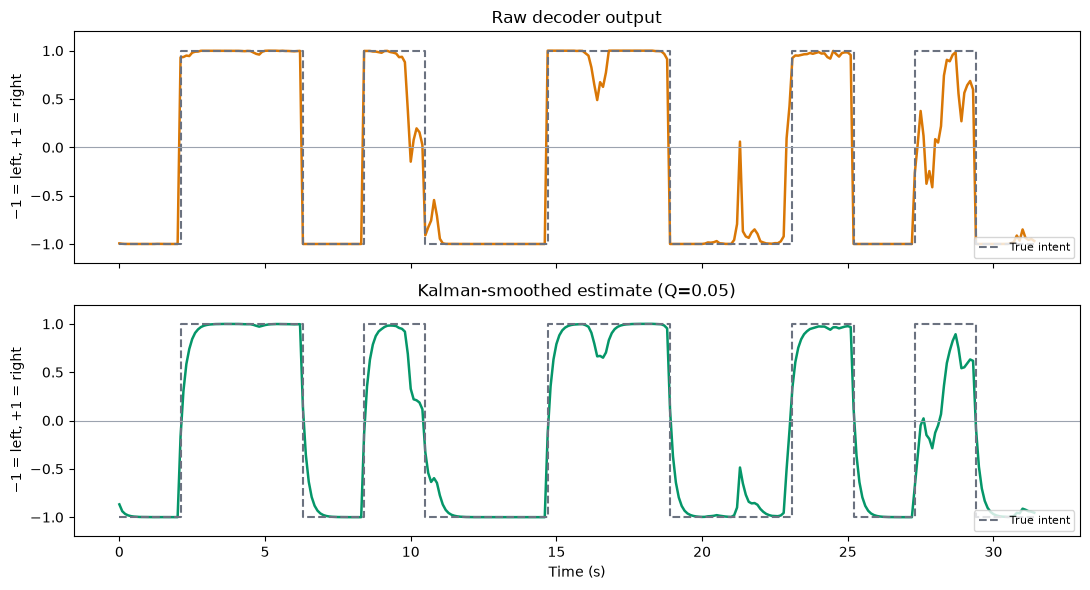

In [20]:
def kalman_filter(z, Q, R, x0=0.0, P0=1.0):
    """1-D Kalman filter: state = intent in [-1, +1], random-walk process model."""
    x, P = x0, P0
    est = np.zeros(len(z))
    gains = np.zeros(len(z))
    for t, zt in enumerate(z):
        P_pred = P + Q                    # predict: intent unchanged, uncertainty grows
        K = P_pred / (P_pred + R)         # Kalman gain
        x = x + K * (zt - x)              # update: nudge toward the new reading
        P = (1 - K) * P_pred
        est[t], gains[t] = x, K
    return est, gains

R = np.var(z_stream - truth_stream)       # empirical measurement noise
Q = 0.05
kf_est, kf_gain = kalman_filter(z_stream, Q, R)

print(f"R (measurement noise) = {R:.3f}   Q (process noise) = {Q}")
print(f"Steady-state Kalman gain ≈ {kf_gain[-1]:.3f}")
for name, est in [("RAW decoder  ", z_stream), ("KALMAN filter", kf_est)]:
    a, r, j, l = evaluate(est)
    print(f"{name}: accuracy = {a:.3f}   regressions = {r}   jitter = {j:.3f}   lag = {l:.2f} s")

# Plot the first ~15 trials
n_show = 15 * n_win
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for ax, sig, title, col in [(axes[0], z_stream, "Raw decoder output", "#d97706"),
                            (axes[1], kf_est, f"Kalman-smoothed estimate (Q={Q})", "#059669")]:
    ax.plot(t_stream[:n_show], sig[:n_show], color=col, linewidth=1.8)
    ax.step(t_stream[:n_show], truth_stream[:n_show], where="post", color="#6b7280", linestyle="--", label="True intent")
    ax.axhline(0, color="#9ca3af", linewidth=0.8)
    ax.set_ylim(-1.2, 1.2)
    ax.set_ylabel("−1 = left, +1 = right")
    ax.set_title(title)
    ax.legend(loc="lower right", fontsize=8)
axes[1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

## Step 4: Smoothness vs. Speed — Sweeping Q

$Q$ is the knob that decides how much the filter trusts new readings. Small $Q$ means "intent rarely changes", which gives heavy smoothing and slower reactions. Large $Q$ means "intent can change any moment", which gives light smoothing and fast reactions. Instead of guessing, we sweep $Q$ and watch all the metrics.

**The three things to look for:**

- **Accuracy:** does smoothing cost correct guesses (because of lag at switches)?
- **Regressions:** does smoothing stop the estimate from falling back to a wrong answer mid-trial?
- **Jitter:** how much does the signal move from step to step? This is what would make a robot arm shake.

We expect jitter to fall as $Q$ shrinks, and accuracy to fall too once the filter becomes too sluggish. The best $Q$ balances the two.

      Q | accuracy | regressions | jitter | lag (s)
    raw |    0.957 |           9 |  0.036 |    0.00
  0.001 |    0.758 |           0 |  0.018 |    0.72
  0.003 |    0.841 |           1 |  0.016 |    0.44
  0.010 |    0.902 |           1 |  0.018 |    0.26
  0.030 |    0.933 |           3 |  0.022 |    0.11
  0.100 |    0.957 |           6 |  0.027 |    0.01
  0.300 |    0.960 |           6 |  0.030 |    0.01
  1.000 |    0.958 |           8 |  0.034 |    0.01


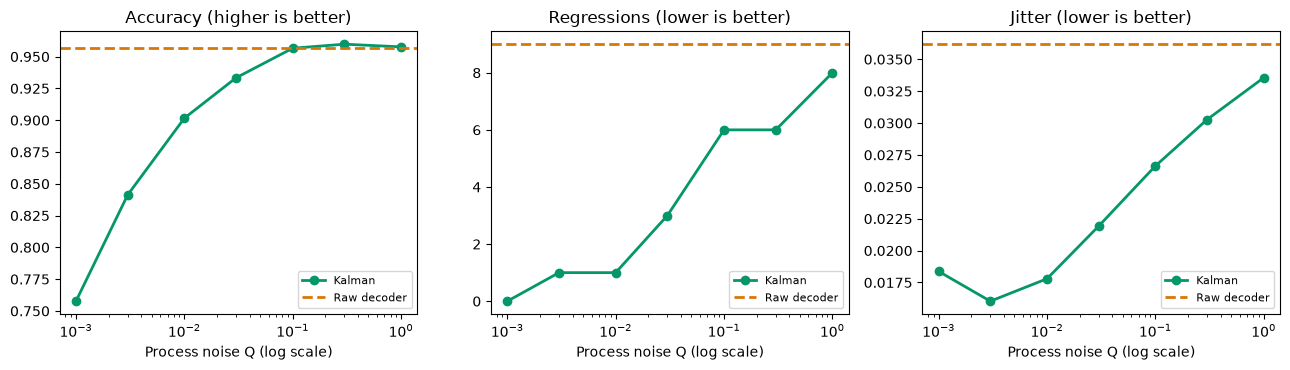

In [21]:
Qs = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0]

raw_metrics = evaluate(z_stream)
rows = []
print(f"{'Q':>7s} | {'accuracy':>8s} | {'regressions':>11s} | {'jitter':>6s} | {'lag (s)':>7s}")
print(f"{'raw':>7s} | {raw_metrics[0]:8.3f} | {raw_metrics[1]:11d} | {raw_metrics[2]:6.3f} | {raw_metrics[3]:7.2f}")
for Q_ in Qs:
    est_, _ = kalman_filter(z_stream, Q_, R)
    m = evaluate(est_)
    rows.append(m)
    print(f"{Q_:7.3f} | {m[0]:8.3f} | {m[1]:11d} | {m[2]:6.3f} | {m[3]:7.2f}")
rows = np.array(rows)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
titles = ["Accuracy (higher is better)", "Regressions (lower is better)", "Jitter (lower is better)"]
for i, ax in enumerate(axes):
    ax.semilogx(Qs, rows[:, i], "o-", color="#059669", linewidth=2, label="Kalman")
    ax.axhline(raw_metrics[i], color="#d97706", linestyle="--", linewidth=2, label="Raw decoder")
    ax.set_xlabel("Process noise Q (log scale)")
    ax.set_title(titles[i])
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Reading the Result (Subject 7)

| | Accuracy | Regressions | Jitter | Lag |
|---|---|---|---|---|
| Raw decoder | 95.7% | 9 | 0.036 | 0.00 s |
| Kalman, Q = 0.03 (heavy smoothing) | 93.3% | 3 | 0.022 | 0.11 s |
| **Kalman, Q = 0.1 (chosen)** | **95.7%** | **6** | **0.027** | **0.01 s** |
| Kalman, Q = 0.3 | 96.0% | 6 | 0.030 | 0.01 s |

- **The smoothing/speed trade-off is real.** Tiny $Q$ gives the smoothest output but a sluggish one: at $Q = 0.001$ the lag is 0.72 s and accuracy falls to 76%.
- **$Q = 0.1$ is the balance point.** Same accuracy as the raw decoder, a third fewer mid-trial slips, about 25% less jitter, and almost no added delay.
- **The gain is modest here, because the raw decoder was already clean** (95.7% per window). The filter removes brief, random glitches. It cannot fix a mistake that lasts several seconds, like the confused stretch near 28 s in the plot.
- **Caveat on two metrics:** the first versions of "flips" and "jitter" counted legitimate left↔right transitions as noise and made the filter look worse than it is. The final versions measure regressions and steady-state jitter only. We keep both fixes visible instead of hiding them.

The real test is a *noisier* decoder, where there is more random noise to remove.

## Step 5: Does the Filter Help More When the Decoder Is Noisier?

We now run the whole pipeline on several subjects: sliding-window decoding, then the Kalman filter with $Q = 0.1$ and $R$ calibrated for each subject. We pick subjects with strong, medium and no decoding signal:

- **7 and 2:** strong decoders
- **1 and 3:** medium
- **5:** decodes at chance. The filter can't create information that isn't there, so this one tests what smoothing does when the decoder is just guessing.

*Note:* in a real system, $R$ would be calibrated from a short calibration session with known intents. Here we use the true labels for that calibration, as we did before.

subj |        | accuracy | regress. | jitter | lag (s)
   7 |    raw |    0.957 |        9 |  0.036 |    0.00
     | Kalman |    0.957 |        6 |  0.027 |    0.01
   2 |    raw |    0.855 |       18 |  0.070 |    0.04
     | Kalman |    0.841 |       14 |  0.057 |    0.12
   1 |    raw |    0.621 |       38 |  0.112 |    0.32
     | Kalman |    0.626 |       24 |  0.056 |    0.23
   3 |    raw |    0.490 |       37 |  0.120 |    0.54
     | Kalman |    0.487 |       20 |  0.060 |    0.65
   5 |    raw |    0.532 |       38 |  0.186 |    0.54
     | Kalman |    0.517 |       23 |  0.080 |    0.56


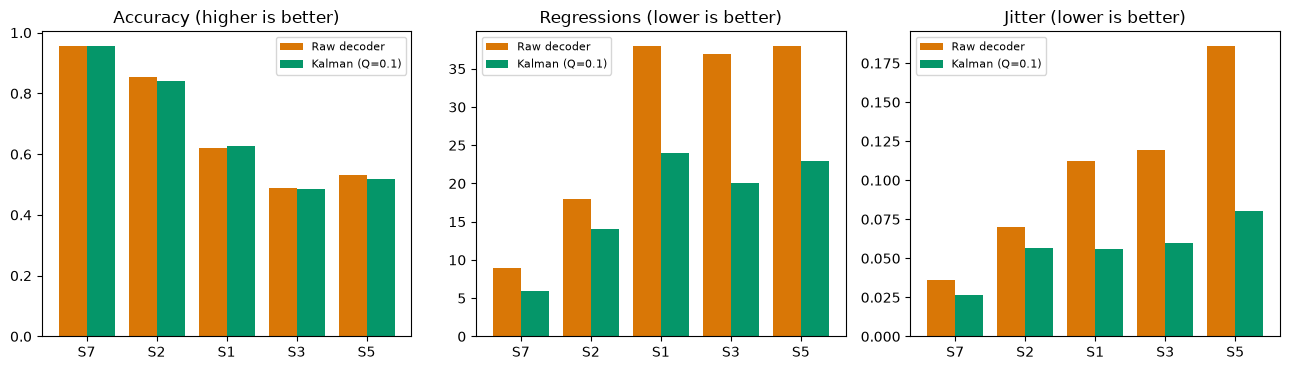

In [22]:
def decode_stream(subject):
    """Sliding-window, out-of-sample P(right) for every trial of one subject."""
    Xs, ys, sf = load_subject(subject)
    wl, st = int(1.5 * sf), int(0.1 * sf)
    Xw_ = np.stack([Xs[:, :, s:s + wl] for s in range(0, Xs.shape[2] - wl + 1, st)], axis=1)
    nt, nw = Xw_.shape[:2]
    p = np.zeros((nt, nw))
    model = Pipeline([("csp", CSP(n_components=4, reg=None, log=True)),
                      ("lda", LinearDiscriminantAnalysis())])
    for tr, te in StratifiedKFold(n_splits=5, shuffle=True, random_state=42).split(Xs, ys):
        model.fit(Xw_[tr].reshape(-1, *Xw_.shape[2:]), np.repeat(ys[tr], nw))
        p[te] = model.predict_proba(Xw_[te].reshape(-1, *Xw_.shape[2:]))[:, 1].reshape(len(te), nw)
    return p, (ys == 3)

def evaluate_stream(est, is_r, dt=0.1):
    nt = len(is_r)
    E = est.reshape(nt, -1)
    correct = (E > 0) == is_r[:, None]
    acc = float(correct.mean())
    regressions = int(np.sum(correct[:, :-1] & ~correct[:, 1:]))
    steady = np.array([k > 0 and is_r[k] == is_r[k - 1] for k in range(nt)])
    jitter = float(np.mean(np.abs(np.diff(E[steady], axis=1))))
    lags = [(np.argmax(correct[k]) if correct[k].any() else E.shape[1]) * dt
            for k in range(1, nt) if is_r[k] != is_r[k - 1]]
    return acc, regressions, jitter, float(np.mean(lags))

Q_final = 0.1
test_subjects = [7, 2, 1, 3, 5]
res = {}
print(f"{'subj':>4s} | {'':>6s} | {'accuracy':>8s} | {'regress.':>8s} | {'jitter':>6s} | {'lag (s)':>7s}")
for s in test_subjects:
    p, is_r = decode_stream(s)
    z = (2 * p - 1).reshape(-1)
    truth = np.repeat(np.where(is_r, 1, -1), p.shape[1])
    R_s = np.var(z - truth)
    est, _ = kalman_filter(z, Q_final, R_s)
    raw_m, kf_m = evaluate_stream(z, is_r), evaluate_stream(est, is_r)
    res[s] = (raw_m, kf_m)
    print(f"{s:4d} | {'raw':>6s} | {raw_m[0]:8.3f} | {raw_m[1]:8d} | {raw_m[2]:6.3f} | {raw_m[3]:7.2f}")
    print(f"{'':4s} | {'Kalman':>6s} | {kf_m[0]:8.3f} | {kf_m[1]:8d} | {kf_m[2]:6.3f} | {kf_m[3]:7.2f}")

# Compare raw vs. Kalman per subject
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
titles = ["Accuracy (higher is better)", "Regressions (lower is better)", "Jitter (lower is better)"]
x = np.arange(len(test_subjects))
for i, ax in enumerate(axes):
    ax.bar(x - 0.2, [res[s][0][i] for s in test_subjects], 0.4, color="#d97706", label="Raw decoder")
    ax.bar(x + 0.2, [res[s][1][i] for s in test_subjects], 0.4, color="#059669", label="Kalman (Q=0.1)")
    ax.set_xticks(x)
    ax.set_xticklabels([f"S{s}" for s in test_subjects])
    ax.set_title(titles[i])
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Summary of Phase 3

**Pipeline:** sliding 1.5 s windows (every 0.1 s) → CSP + LDA, split by trial → decoder stream $z_t \in [-1, 1]$ → 1-D Kalman filter ($Q = 0.1$, $R$ calibrated per subject).

| Subject | Raw accuracy | Kalman accuracy | Regressions | Jitter |
|---|---|---|---|---|
| 7 | 95.7% | 95.7% | 9 → 6 | 0.036 → 0.027 |
| 2 | 85.5% | 84.1% | 18 → 14 | 0.070 → 0.057 |
| 1 | 62.1% | 62.6% | 38 → 24 | 0.112 → 0.056 |
| 3 | 49.0% | 48.7% | 37 → 20 | 0.120 → 0.060 |
| 5 | 53.2% | 51.7% | 38 → 23 | 0.186 → 0.080 |

**What we learned**

- **The filter reliably steadies the signal.** It reduced jitter by 19–57% and mid-trial regressions by 22–46% for every subject, with the biggest relative gains on the noisiest decoders.
- **It does not improve accuracy.** Smoothing removes random glitches; it cannot add information the decoder doesn't have. For subjects 3 and 5, whose decoding is at chance, the output is steadier but still wrong about half the time.
- **Cost:** a small amount of lag at switches (0.01–0.12 s for the better subjects), because the filter has to be convinced that intent really changed.
- **$Q$ was chosen on subject 7 alone** and carried over unchanged to the other four, so the gains are not the result of tuning per subject.

**Caveats:** one pass per subject over 45 trials; $R$ was calibrated using the true labels (a real system would use a short calibration session); the "session" is trials chained end to end with the rest periods removed.

**Next:** Phase 4 feeds the smoothed intent into a simulated robotic arm, closing the loop from brain signal to motion.